# Digits

In [ ]:
from os import X_OK
from sklearn.datasets import load_digits
digits=load_digits()

X=digits.data
y=digits.target
print(X.shape,y.shape)

(1797, 64) (1797,)


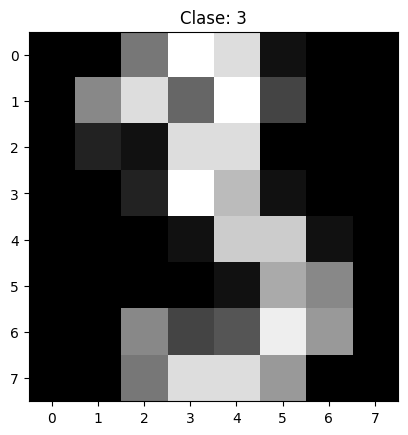

In [ ]:
X_new=X.reshape(-1,8,8)
import matplotlib.pyplot as plt
c=3
plt.imshow(X_new[y==c][0],cmap='gray')
plt.title(f"Clase: {c}")
plt.show()

In [ ]:
!pip install umap-learn
import umap

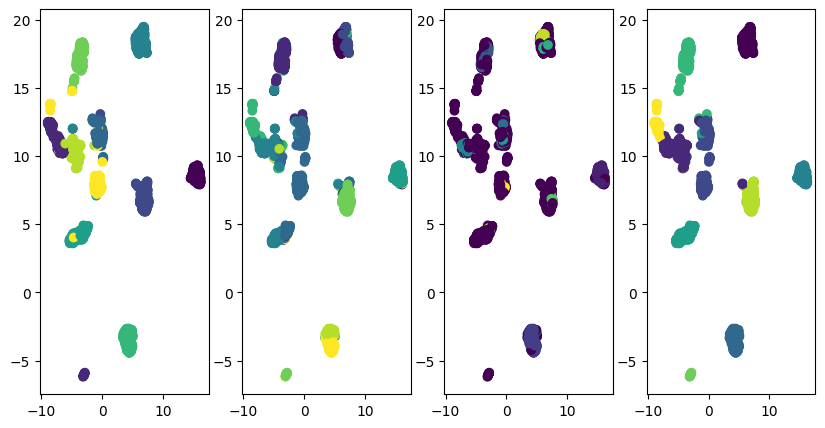

In [ ]:
from sklearn.decomposition  import PCA
from sklearn.manifold import TSNE
model_red=umap.UMAP(n_components=2)
X_pca= model_red.fit_transform(X)
from sklearn.cluster import KMeans,DBSCAN,SpectralClustering
model_Km=KMeans(n_clusters=10)
model_Km.fit(X)
y_Km=model_Km.predict(X)
#####################################
model_DB=DBSCAN(eps=20,min_samples=15)
y_DB=model_DB.fit_predict(X)
#######################################
model_SC=SpectralClustering(n_clusters=10,affinity='nearest_neighbors')
y_SC=model_SC.fit_predict(X)
########################plot###################
fig,axes=plt.subplots(1,4,figsize=(10,5))
axes[0].scatter(X_pca[:,0],X_pca[:,1],c=y)
axes[1].scatter(X_pca[:,0],X_pca[:,1],c=y_Km)
axes[2].scatter(X_pca[:,0],X_pca[:,1],c=y_DB)
axes[3].scatter(X_pca[:,0],X_pca[:,1],c=y_SC)

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train=X_train.reshape(-1,28*28)/255.0
print(X_train.shape,X_train.min(),X_train.max())
#plt.imshow(X_train[145],cmap='gray')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784) 0.0 1.0


In [ ]:
!pip install openTSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 17.2 MB/s eta 0:00:00


In [ ]:
from openTSNE import TSNE
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=42,
    verbose=True,
)
X_tsne = tsne.fit(X_train)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 97.13 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 2.94 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 2.81 seconds
===> Running optimization with exaggeration=12.00, lr=5000.00 for 250 iterations...
Iteration   50, KL divergence 5.8821, 50 iterations in 9.9499 sec
Iteration  100, KL divergence 5.7341, 50 iterations in 10.1454 sec
Iteration  150, KL divergence 5.6946, 50 iterations in 9.2775 sec
Iteration  200, KL divergence 5.6799, 50 iterations in 8.7678 sec
Iteration  250, KL divergence 5.6710, 50 iterations in 9.3634 sec
   --> Time elapsed: 47.51 seconds
===> Running optimization with exaggeratio

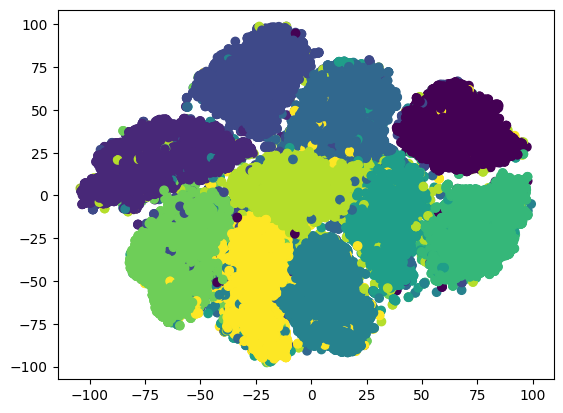

In [ ]:
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_train)

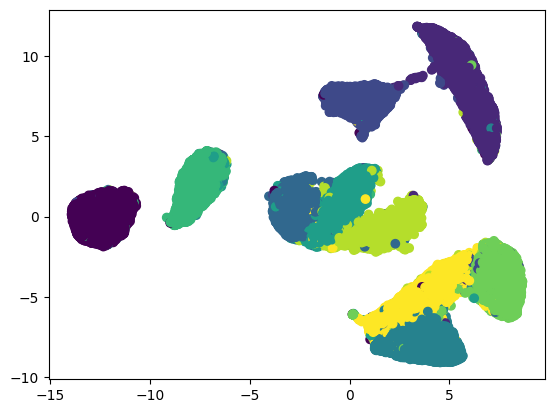

In [ ]:
######USA GPU, se necesita Actibvar##################
import cuml
from cuml.manifold.umap import UMAP as umap
model_red=umap(n_components=2,random_state=42)
X_pca= model_red.fit_transform(X_train)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_train)

#Práctica

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.impute import KNNImputer,SimpleImputer
path=kagglehub.dataset_download("brendan45774/test-file")
print(path)
file_path=f'{path}/tested.csv'
print(file_path)
titanic=pd.read_csv(file_path)
# Copia base
titanic_prepro = titanic.copy()
# 1) Eliminar columna Cabin
titanic_prepro.drop('Cabin', axis=1, inplace=True)
# 2) Codificar Sex (binaria)
titanic_prepro['Sex'] = (
    titanic_prepro['Sex']
    .map({'male': 0, 'female': 1})
    .astype(int)
)
encoder_ohe = OrdinalEncoder()
embarked_ohe = encoder_ohe.fit_transform(titanic_prepro[['Embarked']])
#titanic_prepro.drop('Embarked', axis=1, inplace=True)
titanic_prepro[['Embarked']] = embarked_ohe
# 3) Ordinal Encoding de Ticket
encoder_ord = OrdinalEncoder()
titanic_prepro[['Ticket']] = encoder_ord.fit_transform(
    titanic_prepro[['Ticket']]
)

# 4) Ordinal Encoding de Name
titanic_prepro[['Name']] = encoder_ord.fit_transform(
    titanic_prepro[['Name']]
)

# 5) One-Hot ón de valores faltantes (KNN)
imputer = KNNImputer(n_neighbors=15)
titanic_prepro = pd.DataFrame(
    imputer.fit_transform(titanic_prepro),
    columns=titanic_prepro.columns
)

# 6) Imputaci
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic_prepro_ = pd.DataFrame(
    scaler.fit_transform(titanic_prepro),
    columns=titanic_prepro.columns
)

Using Colab cache for faster access to the 'test-file' dataset.
/kaggle/input/test-file
/kaggle/input/test-file/tested.csv


In [ ]:
titanic_prepro.shape

(418, 11)

0.0 1309.0
0.0 1.0
[2026-02-14 14:06:06.136] [CUML] [info] build_algo set to brute_force_knn because random_state is given


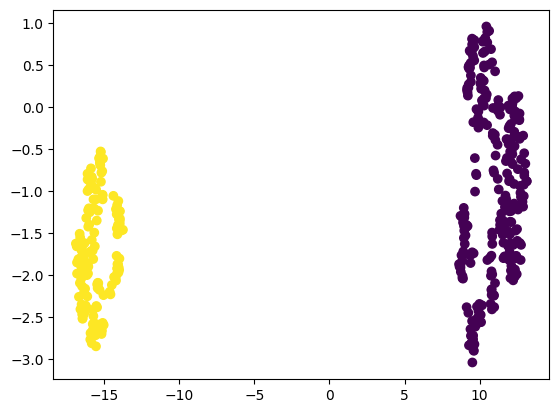

In [ ]:
X=titanic_prepro.values
print(X.min(),X.max())
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X=scaler.fit_transform(X)
print(X.min(),X.max())
######USA GPU, se necesita Actibvar##################
import cuml
from cuml.manifold.umap import UMAP as umap
model_red=umap(n_components=2,
               n_neighbors=200,
               random_state=42)
X_pca= model_red.fit_transform(X)
from sklearn.cluster import KMeans
model_KM=KMeans(n_clusters=6)
model_KM.fit(X_pca)
y_KM=model_KM.predict(X_pca)
plt.scatter(X_pca[:,0],X_pca[:,1],
            c=titanic_prepro['Sex'])

<Axes: >

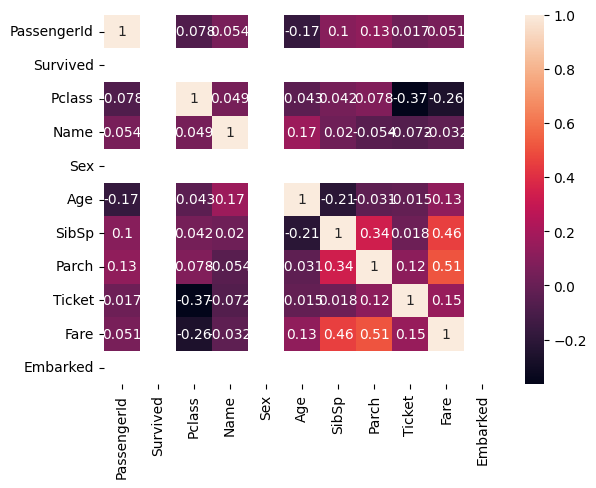

In [ ]:
import seaborn as sns
corr=titanic_prepro[y_KM==1].corr()
sns.heatmap(corr,annot=True)

In [ ]:
titanic[y_KM==]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,909,0,3,"Assaf, Mr. Gerios",male,21.0,0,0,2692,7.2250,NaN,C
20,912,0,1,"Rothschild, Mr. Martin",male,55.0,1,0,PC 17603,59.4000,NaN,C
23,915,0,1,"Williams, Mr. Richard Norris II",male,21.0,0,1,PC 17597,61.3792,NaN,C
27,919,0,3,"Daher, Mr. Shedid",male,22.5,0,0,2698,7.2250,NaN,C
29,921,0,3,"Samaan, Mr. Elias",male,NaN,2,0,2662,21.6792,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
369,1261,0,2,"Pallas y Castello, Mr. Emilio",male,29.0,0,0,SC/PARIS 2147,13.8583,NaN,C
404,1296,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,17765,27.7208,D40,C
405,1297,0,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C
